/tmp/ipython-input-15-3934252136.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2019-01-01")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-15-3934252136.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2019-01-01")


✅ Downloaded 'Close' for Reliance Industries


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-15-3934252136.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2019-01-01")


✅ Downloaded 'Close' for Tata Consultancy Services


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-15-3934252136.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined.fillna(method='ffill', inplace=True)
/tmp/ipython-input-15-3934252136.py:57: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  combined.fillna(method='bfill', inplace=True)


✅ Downloaded 'Close' for HDFC Bank
Missing values in each column:
Reliance Industries          0
Tata Consultancy Services    0
HDFC Bank                    0
dtype: int64

After filling missing values:
Reliance Industries          0
Tata Consultancy Services    0
HDFC Bank                    0
dtype: int64


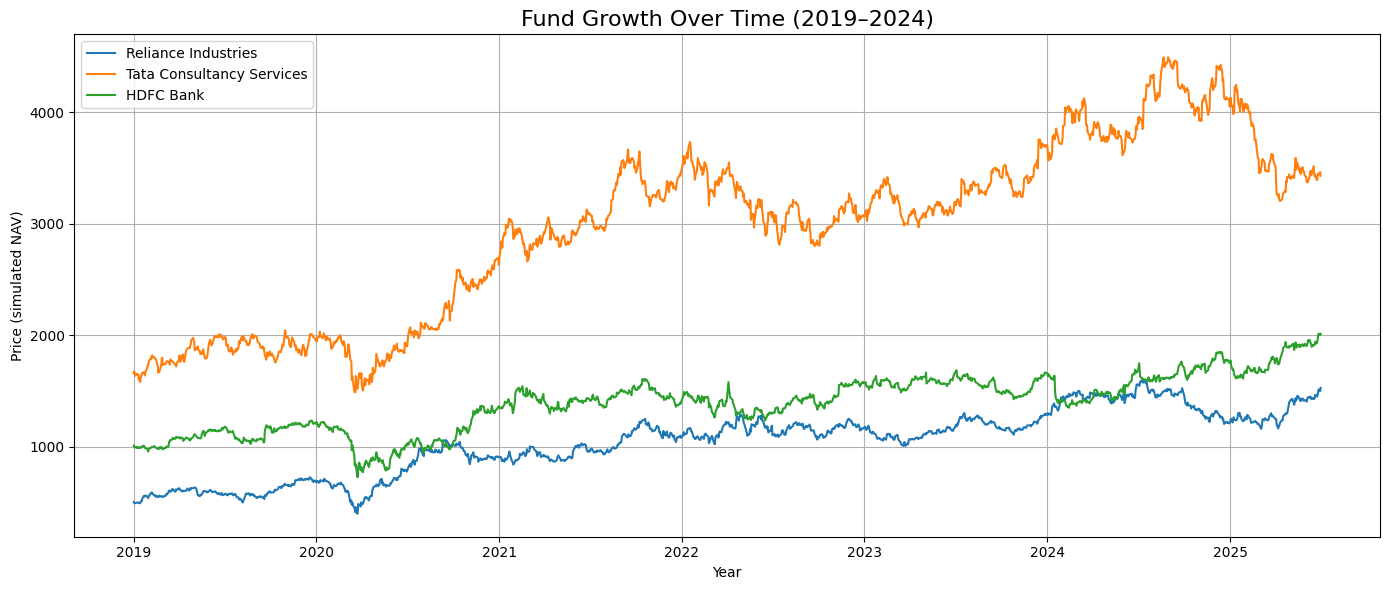

📈 CAGR (Annualized Return for Lump Sum Investment):
Reliance Industries: 18.51%
Tata Consultancy Services: 11.81%
HDFC Bank: 11.17%

📊 SIP Return (5-Year Total Return on ₹1000/month):
Reliance Industries: 58.98%
Tata Consultancy Services: 24.38%
HDFC Bank: 48.57%
⚠️ Risk (Standard Deviation of Daily Returns):
Reliance Industries: 1.82%
Tata Consultancy Services: 1.51%
HDFC Bank: 1.62%


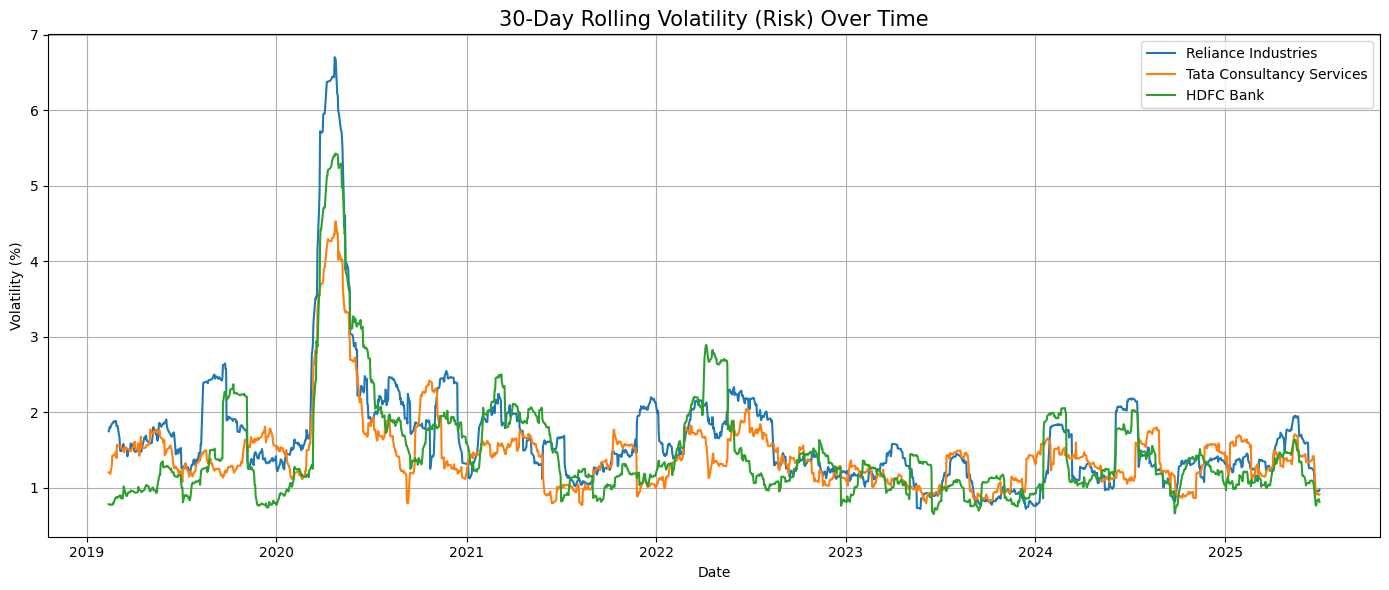

In [ ]:

# Step 1: Install yfinance
!pip install yfinance

# Step 2: Import libraries
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Step 3: Download data for 3 stocks (as mutual fund tickers are often missing from Yahoo Finance)
funds = {
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS",
    "HDFC Bank": "HDFCBANK.NS"
}

# Download last 5 years of NAV/price data
data = {}
all_dates = pd.Index([])  # Empty index to collect all dates

for name, ticker in funds.items():
    try:
        df = yf.download(ticker, start="2019-01-01")
        if not df.empty:
            if 'Adj Close' in df.columns:
                data[name] = df["Adj Close"]
                print(f"✅ Downloaded 'Adj Close' for {name}")
            elif 'Close' in df.columns:
                data[name] = df["Close"]
                print(f"✅ Downloaded 'Close' for {name}")
            else:
                print(f"⚠️ Warning: No valid price column for {name} ({ticker})")

            if name in data:
                all_dates = all_dates.union(data[name].index)
        else:
            print(f"⚠️ Warning: No data downloaded for {name} ({ticker})")
    except Exception as e:
        print(f"❌ Error downloading {name} ({ticker}): {e}")

# Combine all into one DataFrame
combined = pd.DataFrame(index=all_dates)
for name, series in data.items():
    combined[name] = series

# Show first few rows
combined.head()

# Check for missing values
print("Missing values in each column:")
print(combined.isnull().sum())

# Fill missing values using forward-fill method
combined.fillna(method='ffill', inplace=True)

# If still missing, fill remaining with back-fill
combined.fillna(method='bfill', inplace=True)

# Check again
print("\nAfter filling missing values:")
print(combined.isnull().sum())

# Plot NAV (price) growth of each fund
plt.figure(figsize=(14, 6))
for column in combined.columns:
    plt.plot(combined.index, combined[column], label=column)

plt.title("Fund Growth Over Time (2019–2024)", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Price (simulated NAV)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Calculate CAGR for each fund
cagr_results = {}

# Get the first and last date in the data
start_date = combined.index[0]
end_date = combined.index[-1]

# Number of years between start and end
n_years = (end_date - start_date).days / 365.25

# Loop over each fund and calculate CAGR
for fund in combined.columns:
    start_value = combined[fund].iloc[0]
    end_value = combined[fund].iloc[-1]

    cagr = ((end_value / start_value) ** (1 / n_years)) - 1
    cagr_results[fund] = round(cagr * 100, 2)

# Print the results
print("📈 CAGR (Annualized Return for Lump Sum Investment):")
for fund, cagr in cagr_results.items():
    print(f"{fund}: {cagr}%")

# Ensure index is datetime format for resampling
combined.index = pd.to_datetime(combined.index)

# SIP Simulation: Invest ₹1000 every month
sip_results = {}

monthly_data = combined.resample('ME').last()  # 'ME' = month end

for column in monthly_data.columns:
    units = 0
    total_invested = 0

    for price in monthly_data[column]:
        if pd.notnull(price):
            units += 1000 / price  # Buying units each month
            total_invested += 1000

    final_value = units * monthly_data[column].iloc[-1]
    sip_return = ((final_value - total_invested) / total_invested) * 100
    sip_results[column] = round(sip_return, 2)

# Show SIP return for each fund
print("\n📊 SIP Return (5-Year Total Return on ₹1000/month):")
for fund, sip in sip_results.items():
    print(f"{fund}: {sip}%")

# Calculate daily returns for each fund
daily_returns = combined.pct_change()

# Calculate standard deviation of returns (risk)
risk = daily_returns.std() * 100  # in %
risk = risk.round(2)

# Show the results
print("⚠️ Risk (Standard Deviation of Daily Returns):")
for fund, value in risk.items():
    print(f"{fund}: {value}%")

# Calculate rolling standard deviation (volatility) for 30 days
rolling_volatility = daily_returns.rolling(window=30).std() * 100

# Plot it
plt.figure(figsize=(14, 6))
for column in rolling_volatility.columns:
    plt.plot(rolling_volatility.index, rolling_volatility[column], label=column)

plt.title("30-Day Rolling Volatility (Risk) Over Time", fontsize=15)
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

